# Feature Engineering (Distributed Spark)

This notebook builds a dense 10-minute demand table by ZoneID and creates time-series features.

Outputs:
- HDFS: /user/data/feature_engineering/demand_prediction_dense_10m
- HDFS: /user/data/feature_engineering/demand_prediction_features

Time window behavior:
- Auto-detects available min/max timestamp from input data by default.

In [1]:
#!pip install pyspark=3.5.0


In [2]:
import sys, os
sys.path.insert(0, '/opt/spark/python')
sys.path.insert(0, '/opt/spark/python/lib/py4j-0.10.9.7-src.zip')

import urllib.request
import json as js

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import DoubleType, LongType

spark = (
    SparkSession.builder
    .appName("DemandPredictionFeatureEngineering_VirtualCluster")
    .master("spark://master:7077")
    .config("spark.eventLog.enabled", "true")
    .config("spark.eventLog.dir", "hdfs://master:9000/spark-logs")
    .config("spark.driver.memory", "1500m")
    .config("spark.driver.memoryOverhead", "512m")
    .config("spark.executor.memory", "2g")
    .config("spark.executor.memoryOverhead", "512m")
    .config("spark.executor.cores", "2")
    .config("spark.cores.max", "6")
    .config("spark.sql.shuffle.partitions", "24")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

def cluster_util(stage_name):
    import json as _json, urllib.request
    print(f"===== CLUSTER UTILIZATION: {stage_name} =====")
    print("Spark master:", spark.sparkContext.master)
    try:
        info = _json.load(urllib.request.urlopen("http://master:8080/json/"))
        workers = info.get("workers", [])
        alive = [w for w in workers if w.get("state") == "ALIVE"]
        apps = info.get("activeapps", [])
        print("alive workers:", len(alive))
        print("active apps :", len(apps))
        for w in alive:
            print("worker", w.get("id"),
                  "cores", f"{w.get('coresused',0)}/{w.get('cores',0)}",
                  "mem(MB)", f"{w.get('memoryused',0)}/{w.get('memory',0)}")
    except Exception as e:
        print("Could not query Spark Standalone Master:", e)


cluster_util("session_started")



:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f32a9878-bde2-4cbe-baa8-03c20b3ea7ee;1.0
	confs: [default]
	found graphframes#graphframes;0.8.3-spark3.5-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
:: resolution report :: resolve 119ms :: artifacts dl 4ms
	:: modules in use:
	graphframes#graphframes;0.8.3-spark3.5-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||   2   |   0   |
	-----------------------------------------------

===== CLUSTER UTILIZATION: session_started =====
Spark master: spark://master:7077
alive workers: 2
active apps : 1
worker worker-20260429064735-172.18.0.4-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429064825-172.18.0.2-7078 cores 2/2 mem(MB) 2048/2048


## Data Preprocessing (In-Memory)

- Parse pickup timestamp from supported columns
- Keep non-null ZoneID and ZoneID > 0
- Detect timestamp outliers using IQR (Q1/Q3, Tukey fences), no fixed year hardcode

In [3]:
# === CONFIGURATION ===
RAW_PATH = "hdfs://master:9000/user/data/raw/yellow_tripdata_*.parquet"
PICKUP_COL_CANDIDATES = ["tpep_pickup_datetime", "pickup_datetime"]
ZONE_COL = "PULocationID"
BIN_COL = "pickup_bin_10m"
TARGET_COL = "pickup_demand"

# Lọc dữ liệu trong 6 năm (2020 - 2025)
START_TS = "2020-01-01 00:00:00"
END_TS = "2025-12-31 23:59:59"

OUT_DENSE = "hdfs://master:9000/user/data/feature_engineering/demand_prediction_dense_10m"
OUT_FEATURES = "hdfs://master:9000/user/data/feature_engineering/demand_prediction_features"



In [4]:
import json as _json

# Identify files via Hadoop FileSystem API
sc = spark.sparkContext
fs = sc._jvm.org.apache.hadoop.fs.FileSystem.get(sc._jsc.hadoopConfiguration())
FileStatus_arr = fs.globStatus(sc._jvm.org.apache.hadoop.fs.Path(RAW_PATH))
file_paths = [status.getPath().toString() for status in FileStatus_arr]

print(f"Found {len(file_paths)} parquet files to process individually.")

dfs = []
for path in file_paths:
    temp_df = spark.read.parquet(path)
    
    # Identify timestamp column
    pickup_col = next((c for c in PICKUP_COL_CANDIDATES if c in temp_df.columns), None)
    if pickup_col is None or ZONE_COL not in temp_df.columns:
        print(f"Skipping {path} due to missing required columns.")
        continue
        
    # Select and safely cast right at the file boundary
    cleaned = temp_df.select(
        F.to_timestamp(F.col(pickup_col)).alias("pickup_ts"),
        F.col(ZONE_COL).cast("int").alias(ZONE_COL)
    )
    dfs.append(cleaned)

if not dfs:
    raise ValueError("No valid parquet files found!")

from functools import reduce
raw_df = reduce(lambda a, b: a.unionByName(b), dfs)

# Pre-filter by year and CACHE immediately - this avoids re-reading 72 parquet files multiple times
typed_df = (
    raw_df
    .where(F.year("pickup_ts").between(int(START_TS[:4]), int(END_TS[:4])))
    .cache()
)

# Trigger the cache with count, then compute all stats from memory
raw_rows = typed_df.count()

# Compute all quality metrics in a single aggregation (one pass over cached data)
quality_stats = typed_df.agg(
    F.sum(F.when(F.col("pickup_ts").isNull(), 1).otherwise(0)).alias("null_pickup"),
    F.sum(F.when(F.col(ZONE_COL).isNull(), 1).otherwise(0)).alias("null_zone"),
    F.sum(F.when(F.col(ZONE_COL) <= 0, 1).otherwise(0)).alias("nonpositive_zone"),
).first()
null_pickup_rows = int(quality_stats["null_pickup"])
null_zone_rows = int(quality_stats["null_zone"])
nonpositive_zone_rows = int(quality_stats["nonpositive_zone"])

# --- TIMESTAMP OUTLIER CLEANING (IQR METHOD) ---
# percentile_approx on cached data (no more re-reading files)
iqr_bounds = typed_df.where(F.col("pickup_ts").isNotNull()).agg(
    F.expr("percentile_approx(unix_timestamp(pickup_ts), 0.25, 10000)").alias("q1_epoch"),
    F.expr("percentile_approx(unix_timestamp(pickup_ts), 0.75, 10000)").alias("q3_epoch")
).first()

if iqr_bounds["q1_epoch"] is None or iqr_bounds["q3_epoch"] is None:
    raise ValueError("Cannot compute IQR bounds for pickup timestamp.")

q1_epoch = int(iqr_bounds["q1_epoch"])
q3_epoch = int(iqr_bounds["q3_epoch"])
iqr_epoch = max(q3_epoch - q1_epoch, 1)
lower_epoch = q1_epoch - int(1.5 * iqr_epoch)
upper_epoch = q3_epoch + int(1.5 * iqr_epoch)

lower_ts = pd.to_datetime(lower_epoch, unit="s")
upper_ts = pd.to_datetime(upper_epoch, unit="s")

# Build base_trips from cached typed_df (fast - no re-read from HDFS)
base_trips = (
    typed_df
    .where(F.col("pickup_ts").isNotNull())
    .where(F.col(ZONE_COL).isNotNull())
    .where(F.col(ZONE_COL) > 0)
    .where(F.unix_timestamp("pickup_ts").between(lower_epoch, upper_epoch))
    .cache()  # Cache base_trips too since it's reused in next cell
)

# Compute time outlier count + bounds + clean_rows in one pass
agg_results = base_trips.agg(
    F.count("*").alias("clean_rows"),
    F.min("pickup_ts").alias("min_ts"),
    F.max("pickup_ts").alias("max_ts")
).first()
clean_rows = int(agg_results["clean_rows"])
available_bounds = agg_results

# Outliers = raw - null - nonpositive - clean (derived, no extra scan needed)
time_outlier_rows_iqr = raw_rows - null_pickup_rows - null_zone_rows - nonpositive_zone_rows - clean_rows
time_outlier_rows_iqr = max(0, time_outlier_rows_iqr)  # guard against rounding

print("IQR timestamp bounds:", lower_ts, "->", upper_ts)
print("Cleaned available range:", available_bounds["min_ts"], "->", available_bounds["max_ts"])

cleaning_report = pd.DataFrame(
    [
        {"metric": "raw_rows", "count": int(raw_rows)},
        {"metric": "removed_null_pickup_ts", "count": int(null_pickup_rows)},
        {"metric": "removed_null_zone", "count": int(null_zone_rows)},
        {"metric": "removed_nonpositive_zone", "count": int(nonpositive_zone_rows)},
        {"metric": "removed_time_outliers_iqr", "count": int(time_outlier_rows_iqr)},
        {"metric": "rows_after_cleaning", "count": int(clean_rows)},
    ]
)
display(cleaning_report)
cluster_util("after_preprocessing")



Found 72 parquet files to process individually.


IQR timestamp bounds: 2017-10-10 11:23:12 -> 2029-01-28 16:08:59
Cleaned available range: 2020-01-01 00:00:00 -> 2025-12-31 23:59:59


,metric,count
0,raw_rows,223410839
1,removed_null_pickup_ts,0
2,removed_null_zone,0
3,removed_nonpositive_zone,0
4,removed_time_outliers_iqr,0
5,rows_after_cleaning,223410839


===== CLUSTER UTILIZATION: after_preprocessing =====
Spark master: spark://master:7077
alive workers: 2
active apps : 1
worker worker-20260429064735-172.18.0.4-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429064825-172.18.0.2-7078 cores 2/2 mem(MB) 2048/2048


In [5]:
effective_start = START_TS if START_TS is not None else available_bounds["min_ts"]
effective_end = END_TS if END_TS is not None else available_bounds["max_ts"]

window_cond = F.col("pickup_ts") >= F.lit(effective_start)
if END_TS is not None:
    window_cond = window_cond & (F.col("pickup_ts") < F.lit(effective_end))
else:
    window_cond = window_cond & (F.col("pickup_ts") <= F.lit(effective_end))

trips = base_trips.where(window_cond)
trip_rows = trips.count()
if trip_rows == 0:
    raise ValueError(
        f"No rows in requested period [{effective_start}, {effective_end}]. "
        f"Available cleaned range is [{available_bounds['min_ts']}, {available_bounds['max_ts']}]."
    )

print("Effective window:", effective_start, "->", effective_end)
print("Trips used after preprocessing:", trip_rows)
cluster_util("after_raw_filter")


Effective window: 2020-01-01 00:00:00 -> 2025-12-31 23:59:59
Trips used after preprocessing: 223410838
===== CLUSTER UTILIZATION: after_raw_filter =====
Spark master: spark://master:7077
alive workers: 2
active apps : 1
worker worker-20260429064735-172.18.0.4-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429064825-172.18.0.2-7078 cores 2/2 mem(MB) 2048/2048


In [7]:
demand_10m_raw = (
    trips
    .withColumn(BIN_COL, F.to_timestamp(F.from_unixtime(F.floor(F.unix_timestamp("pickup_ts") / 3600) * 3600)))
    .groupBy(ZONE_COL, BIN_COL)
    .agg(F.count(F.lit(1)).cast("double").alias(TARGET_COL))
    .cache()  # Cache to avoid recomputing the heavy groupBy twice
)

# Materialize the cache immediately before IQR computation
demand_bin_count = demand_10m_raw.count()
print(f"Total demand bins: {demand_bin_count}")

# --- DEMAND OUTLIER CLEANING (IQR METHOD) ---
# Remove extreme spikes in demand (e.g. 10,000 pickups in 10 mins in one zone)
demand_stats = demand_10m_raw.agg(
    F.expr("percentile_approx(pickup_demand, 0.25, 10000)").alias("q1"),
    F.expr("percentile_approx(pickup_demand, 0.75, 10000)").alias("q3")
).first()

q1_d = demand_stats["q1"]
q3_d = demand_stats["q3"]
iqr_d = q3_d - q1_d
# Using a slightly looser multiplier for demand spikes (3.0 for "extreme outliers")
upper_bound_d = q3_d + 3.0 * iqr_d

demand_outliers = demand_10m_raw.where(F.col(TARGET_COL) > upper_bound_d).count()
print(f"Demand IQR bounds: up to {upper_bound_d} pickups/10m. Removed {demand_outliers} outliers.")

demand_10m = demand_10m_raw.where(F.col(TARGET_COL) <= upper_bound_d)

# Lọc các zone có hoạt động trên 5% thời gian để giảm nhiễu và RAM
n_bins_total = (F.unix_timestamp(F.lit(effective_end)) - F.unix_timestamp(F.lit(effective_start))) / 3600
active_zones = (
    demand_10m.groupBy(ZONE_COL)
    .agg(F.count(F.lit(1)).alias("active_bins"))
    .withColumn("active_ratio", F.col("active_bins") / n_bins_total)
    .filter(F.col("active_ratio") >= 0.05)
    .select(ZONE_COL)
)
zone_dim = active_zones
time_bounds = demand_10m.agg(F.min(BIN_COL).alias("min_ts"), F.max(BIN_COL).alias("max_ts")).first()

if time_bounds["min_ts"] is None or time_bounds["max_ts"] is None:
    raise ValueError("No demand rows found in selected period.")

time_dim = (
    spark.range(1)
    .select(F.sequence(F.lit(time_bounds["min_ts"]), F.lit(time_bounds["max_ts"]), F.expr("interval 60 minutes")).alias("bins"))
    .select(F.explode(F.col("bins")).alias(BIN_COL))
)

dense_df = (
    zone_dim.crossJoin(time_dim)
    .join(demand_10m, on=[ZONE_COL, BIN_COL], how="left")
    .fillna({TARGET_COL: 0.0})
    .repartition(24, ZONE_COL)
    .cache()
)

dense_rows = dense_df.count()
print("Dense rows:", dense_rows)
cluster_util("after_dense_table")



Total demand bins: 6165831


Demand IQR bounds: up to 129.0 pickups/10m. Removed 566903 outliers.


26/04/29 07:49:29 WARN DAGScheduler: Broadcasting large task binary with size 1453.5 KiB
26/04/29 07:49:31 WARN DAGScheduler: Broadcasting large task binary with size 1466.9 KiB


Dense rows: 12047232
===== CLUSTER UTILIZATION: after_dense_table =====
Spark master: spark://master:7077
alive workers: 2
active apps : 1
worker worker-20260429064735-172.18.0.4-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429064825-172.18.0.2-7078 cores 2/2 mem(MB) 2048/2048


In [8]:
w = Window.partitionBy(ZONE_COL).orderBy(BIN_COL)
w_hist_6 = w.rowsBetween(-6, -1)
w_hist_18 = w.rowsBetween(-18, -1)
w_count = Window.partitionBy(ZONE_COL)

features_df = (
    dense_df
    .withColumn("hour", F.hour(BIN_COL).cast("double"))
    .withColumn("dow", F.dayofweek(BIN_COL).cast("double"))
    .withColumn("month", F.month(BIN_COL).cast("double"))
    .withColumn("is_weekend", F.when(F.dayofweek(BIN_COL).isin([1, 7]), F.lit(1.0)).otherwise(F.lit(0.0)))
    .withColumn("lag_1", F.lag(TARGET_COL, 1).over(w).cast("double"))
    .withColumn("lag_2", F.lag(TARGET_COL, 2).over(w).cast("double"))
    .withColumn("lag_3", F.lag(TARGET_COL, 3).over(w).cast("double"))
    .withColumn("lag_6", F.lag(TARGET_COL, 6).over(w).cast("double"))
    .withColumn("lag_12", F.lag(TARGET_COL, 12).over(w).cast("double"))
    .withColumn("lag_24", F.lag(TARGET_COL, 24).over(w).cast("double"))
    .withColumn("roll_mean_6", F.avg(TARGET_COL).over(w_hist_6).cast("double"))
    .withColumn("roll_mean_18", F.avg(TARGET_COL).over(w_hist_18).cast("double"))
    .withColumn("roll_std_18", F.stddev_pop(TARGET_COL).over(w_hist_18).cast("double"))
    .dropna()
    .withColumn("rn", F.row_number().over(w))
    .withColumn("n_zone", F.count(F.lit(1)).over(w_count))
    .withColumn("train_cut", F.floor(F.col("n_zone") * F.lit(0.7)))
    .withColumn("split", F.when(F.col("rn") <= F.col("train_cut"), F.lit("train")).otherwise(F.lit("test")))
    .cache()
)

feature_rows = features_df.count()
print("Feature rows:", feature_rows)
features_df.groupBy("split").count().show()
cluster_util("after_feature_engineering")


Feature rows: 12041736
+-----+-------+
|split|  count|
+-----+-------+
|train|8429032|
| test|3612704|
+-----+-------+

===== CLUSTER UTILIZATION: after_feature_engineering =====
Spark master: spark://master:7077
alive workers: 2
active apps : 1
worker worker-20260429064735-172.18.0.4-7078 cores 2/2 mem(MB) 2048/2048
worker worker-20260429064825-172.18.0.2-7078 cores 2/2 mem(MB) 2048/2048


In [9]:
dense_df.write.mode("overwrite").parquet(OUT_DENSE)
features_df.write.mode("overwrite").parquet(OUT_FEATURES)

run_meta = {
    "raw_path": RAW_PATH,
    "pickup_column": pickup_col,
    "effective_start": str(effective_start),
    "effective_end": str(effective_end),
    "dense_rows": int(dense_rows),
    "feature_rows": int(feature_rows),
    "cleaning_summary": {
        "raw_rows": int(raw_rows),
        "removed_null_pickup_ts": int(null_pickup_rows),
        "removed_null_zone": int(null_zone_rows),
        "removed_nonpositive_zone": int(nonpositive_zone_rows),
        "removed_time_outliers_iqr": int(time_outlier_rows_iqr),
        "iqr_lower_ts": str(lower_ts),
        "iqr_upper_ts": str(upper_ts),
        "rows_after_cleaning": int(clean_rows),
    },
    "hdfs_outputs": {
        "dense": OUT_DENSE,
        "features": OUT_FEATURES,
    },
}


print("Saved HDFS outputs:")
print("-", OUT_DENSE)
print("-", OUT_FEATURES)


Saved HDFS outputs:
- hdfs://master:9000/user/data/feature_engineering/demand_prediction_dense_10m
- hdfs://master:9000/user/data/feature_engineering/demand_prediction_features


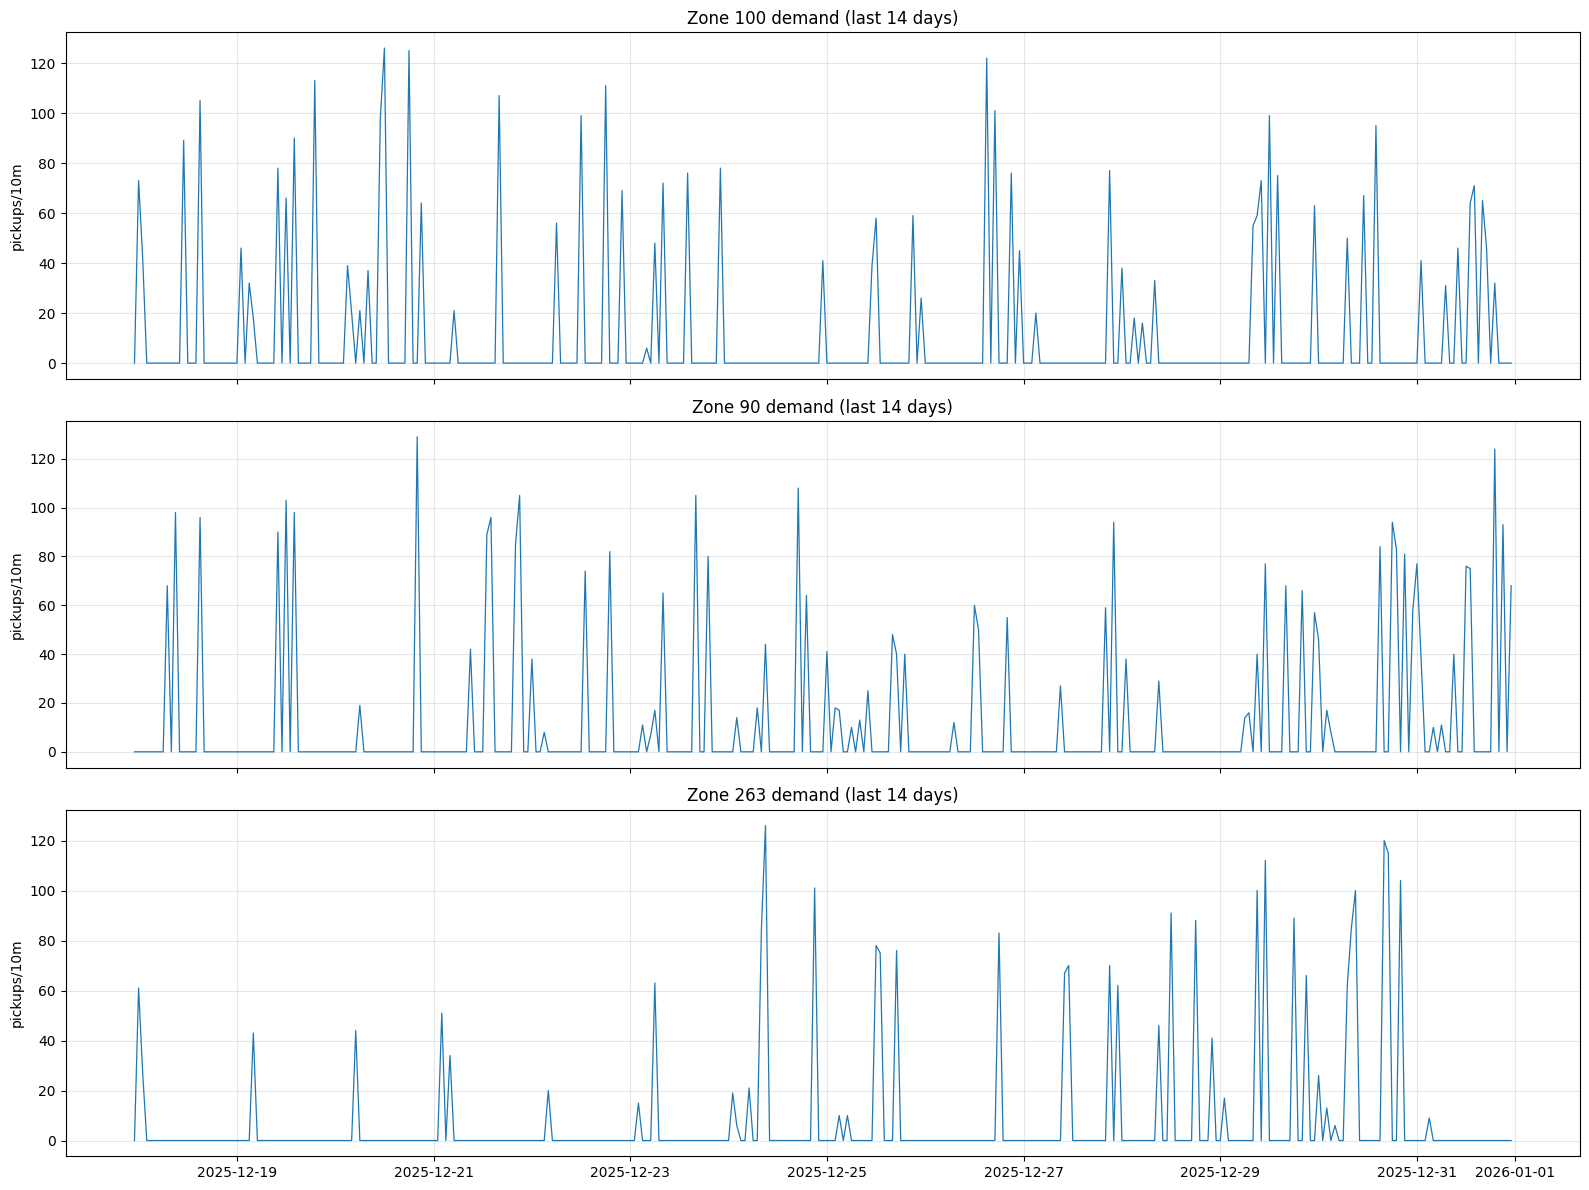

In [10]:
zone_rank = (
    dense_df.groupBy(ZONE_COL).agg(F.sum(TARGET_COL).alias("total"))
    .orderBy(F.col("total").desc())
    .limit(3)
)
top_zones = [r[ZONE_COL] for r in zone_rank.collect()]

max_bin = dense_df.agg(F.max(BIN_COL).alias("max_bin")).first()["max_bin"]
plot_start = pd.Timestamp(max_bin) - pd.Timedelta(days=14)

plot_df = (
    dense_df.where(F.col(ZONE_COL).isin(top_zones))
    .where(F.col(BIN_COL) >= F.to_timestamp(F.lit(str(plot_start))))
    .orderBy(ZONE_COL, BIN_COL)
    .toPandas()
)


if len(plot_df) > 0:

    fig, axes = plt.subplots(len(top_zones), 1, figsize=(16, 4 * len(top_zones)), sharex=True)
    if len(top_zones) == 1:
        axes = [axes]
    for ax, z in zip(axes, top_zones):
        tmp = plot_df[plot_df[ZONE_COL] == z]
        ax.plot(tmp[BIN_COL], tmp[TARGET_COL], linewidth=0.9)
        ax.set_title(f"Zone {z} demand (last 14 days)")
        ax.set_ylabel("pickups/10m")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("No data for plotting.")


In [11]:
spark.catalog.clearCache()
spark.stop()
print("Feature engineering Spark session stopped.")


Feature engineering Spark session stopped.
